In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle

# Load dataset
df = pd.read_csv('phishing.csv')
X = df.drop(columns=['Index', 'class'])
y = df['class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Show Accuracy
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"✅ Model Accuracy: {accuracy * 100:.2f}%")

✅ Model Accuracy: 96.92%


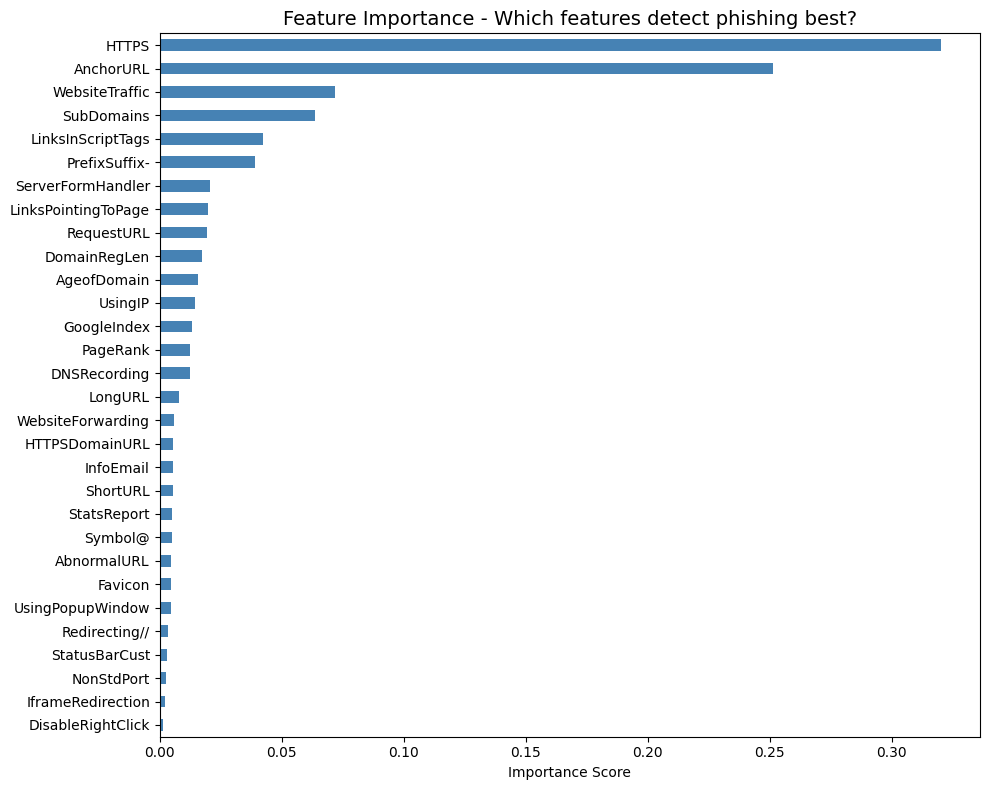

In [2]:
import matplotlib.pyplot as plt

# Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values()

# Plot
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Which features detect phishing best?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

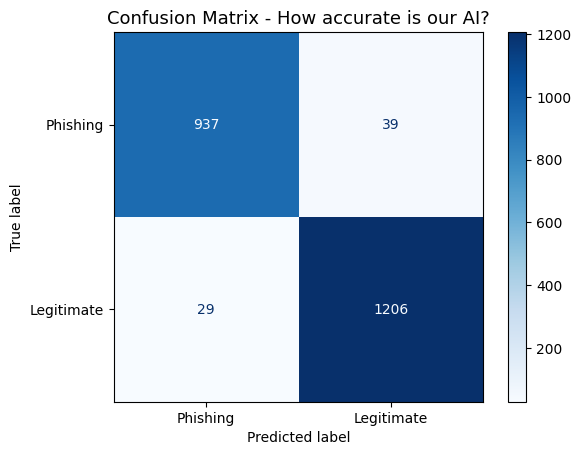

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legitimate'])

# Plot
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - How accurate is our AI?', fontsize=13)
plt.show()

In [4]:
import re

def predict_url(url):
    features = {name: 1 for name in X.columns}
    url_lower = url.lower().strip()
    domain_part = url_lower.split('://')[-1].split('/')[0]
    domain_name = domain_part.split('.')[0]

    if re.search(r"(\d{1,3}\.){3}\d{1,3}", domain_part):
        features['UsingIP'] = -1
    if len(url_lower) > 75:
        features['LongURL'] = -1
    if any(s in domain_part for s in ['bit.ly','tinyurl','t.co']):
        features['ShortURL'] = -1
    if '@' in url_lower:
        features['Symbol@'] = -1
    if '-' in domain_part:
        features['PrefixSuffix-'] = -1
    if not url_lower.startswith('https'):
        features['HTTPS'] = -1

    df_input = pd.DataFrame([features], columns=X.columns)
    result = model.predict(df_input)[0]

    if result == -1:
        print(f"🚨 PHISHING WEBSITE DETECTED: {url}")
    else:
        print(f"✅ LEGITIMATE WEBSITE: {url}")

# Test live in front of your teacher!
predict_url("http://192.168.1.1/login/bank")
predict_url("https://www.google.com")
predict_url("http://bit.ly/secure-login")
predict_url("https://facbok.com")
predict_url("https://facebook.com")

✅ LEGITIMATE WEBSITE: http://192.168.1.1/login/bank
✅ LEGITIMATE WEBSITE: https://www.google.com
✅ LEGITIMATE WEBSITE: http://bit.ly/secure-login
✅ LEGITIMATE WEBSITE: https://facbok.com
✅ LEGITIMATE WEBSITE: https://facebook.com


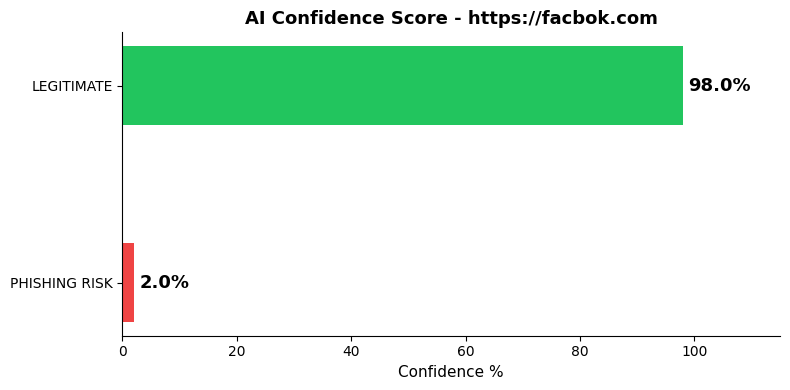

Phishing Probability:  2.0%
Legitimate Probability: 98.0%


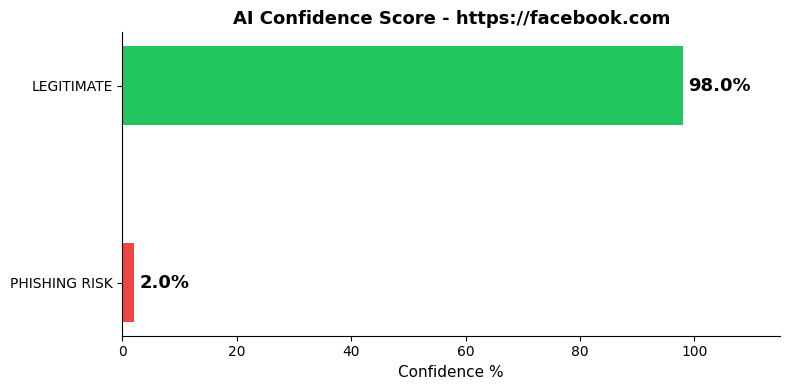

Phishing Probability:  2.0%
Legitimate Probability: 98.0%


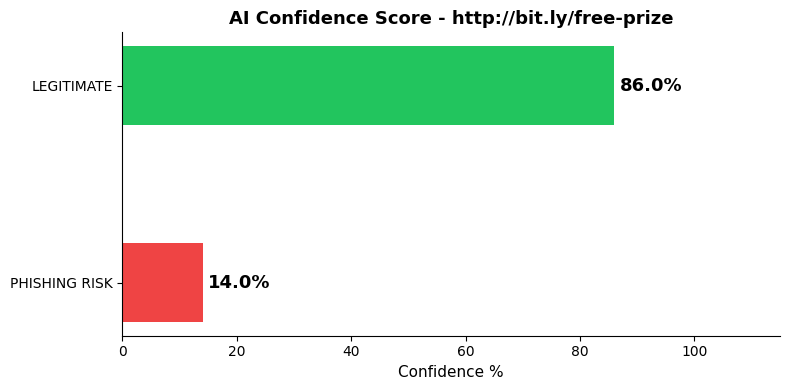

Phishing Probability:  14.0%
Legitimate Probability: 86.0%


In [7]:
import re
import numpy as np

def show_probability_chart(url):
    features = {name: 1 for name in X.columns}
    url_lower = url.lower().strip()
    domain_part = url_lower.split('://')[-1].split('/')[0]

    if re.search(r"(\d{1,3}\.){3}\d{1,3}", domain_part):
        features['UsingIP'] = -1
    if len(url_lower) > 75:
        features['LongURL'] = -1
    if any(s in domain_part for s in ['bit.ly','tinyurl','t.co']):
        features['ShortURL'] = -1
    if '@' in url_lower:
        features['Symbol@'] = -1
    if '-' in domain_part:
        features['PrefixSuffix-'] = -1
    if not url_lower.startswith('https'):
        features['HTTPS'] = -1

    df_input = pd.DataFrame([features], columns=X.columns)
    proba = model.predict_proba(df_input)[0]

    phish_pct = round(proba[0] * 100, 2)
    legit_pct = round(proba[1] * 100, 2)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(
        ['PHISHING RISK', 'LEGITIMATE'],
        [phish_pct, legit_pct],
        color=['#ef4444', '#22c55e'],
        height=0.4
    )

    for bar, pct in zip(bars, [phish_pct, legit_pct]):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{pct}%',
            va='center',
            fontsize=13,
            fontweight='bold'
        )

    ax.set_xlim(0, 115)
    ax.set_xlabel('Confidence %', fontsize=11)
    ax.set_title(f'AI Confidence Score - {url}', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    print(f"Phishing Probability:  {phish_pct}%")
    print(f"Legitimate Probability: {legit_pct}%")

# Test these URLs
show_probability_chart("https://facbok.com")
show_probability_chart("https://facebook.com")
show_probability_chart("http://bit.ly/free-prize")